# Long term

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ipywidgets import interact, widgets
from IPython.display import display

In [2]:
%load_ext autoreload

In [24]:
#Run this to reload the python file
%autoreload 2
from utils import *

## Import data

In [4]:
# read the file with the pcp information from GPM and IMN
imn_df = pd.read_csv('./Data/harmonized/unif_IMN.csv')
gpm_df = pd.read_csv('./Data/harmonized/unif_GPM.csv')

In [ ]:
#meta = pd.read_csv('./Data/metadata/IMN_stations_rev.csv')

In [ ]:
#gpm_coord = pd.read_csv('./Data/metadata/gpm_coords.csv')

In [5]:
meta_df = pd.read_csv('./Data/metadata/long_term_v07.csv')

## Pre process

In [8]:
# check the len of the dfs
print(len(imn_df))
print(len(gpm_df))

192840
192840


In [9]:
# assigning 'date' as index
imn_df = convert_index(imn_df, 'date')
gpm_df = convert_index(gpm_df, 'date')

/opt/homebrew/lib/python3.11/site-packages/pandas/core/indexes/base.py:7588: FutureWarning: Dtype inference on a pandas object (Series, Index, ExtensionArray) is deprecated. The Index constructor will keep the original dtype in the future. Call `infer_objects` on the result to get the old behavior.
  return Index(sequences[0], name=names)
/opt/homebrew/lib/python3.11/site-packages/pandas/core/indexes/base.py:7588: FutureWarning: Dtype inference on a pandas object (Series, Index, ExtensionArray) is deprecated. The Index constructor will keep the original dtype in the future. Call `infer_objects` on the result to get the old behavior.
  return Index(sequences[0], name=names)


In [11]:
# match gpm_df dates with imn_df
imn_df = imn_df['2001-01-01 00:00:00':'2022-12-31 23:00:00']
gpm_df = gpm_df['2001-01-01 00:00:00':'2022-12-31 23:00:00']

In [12]:
temp_resol = {
    '1D': '1 día',
    '7D': '1 semana',
    '1M': '1 mes'
}

In [ ]:
#merged_df = pd.merge(meta, gpm_coord, left_on='Número', right_on='number')

In [ ]:
#merged_df = merged_df.drop(columns=['Unnamed: 0.1_x', 'Unnamed: 0_x', 'station_number', 'Unnamed: 0.1_y', 'Unnamed: 0_y', 'number'])

## Analysis

### Correlations

In [ ]:
corr_temp = []
for window in temp_resol.keys():
    tmp = corr_accum(imn_df, gpm_df, window)
    result_dict = {
        'window': window,
        'correlation': tmp.get('correlation')
    }
    corr_temp.append(result_dict)

In [ ]:
df = pd.DataFrame()
df['1D'] = corr_temp[0]['correlation']
df['7D'] = corr_temp[1]['correlation']
df['1M'] = corr_temp[2]['correlation']

In [ ]:
df = df.reset_index()
df.rename(columns={'index': 'numero'}, inplace=True)

In [ ]:
df['numero'] = df['numero'].astype(float)

In [ ]:
merged_df = pd.merge(merged_df, df, left_on='Número', right_on='numero')
merged_df = merged_df.drop(columns=['numero'])

### Distance between points

In [ ]:
#gpm_coord['distance'] = gpm_coord.apply(lambda row: haversine(row['lat'],
#                                                              row['lon'],
#                                                              meta.loc[meta['station_number'] == row['number'], 'lat'].iloc[0],
#                                                              meta.loc[meta['station_number'] == row['number'], 'lon'].iloc[0]),
#                                        axis=1)

In [ ]:
#gpm_coord.to_csv('./Data/metadata/gpm_coords.csv')

In [ ]:
#tmp = meta.merge(gpm_coord, left_on='Número', right_on='number')
#tmp = tmp.merge(df, left_on='Número', right_on='numero')
#tmp = tmp.drop(columns=['Unnamed: 0.1_x', 'Unnamed: 0_x', 'station_number', 'Unnamed: 0.1_y','Unnamed: 0_y', 'number', 'numero'])
#tmp.to_csv('./Data/metadata/long_term_v07.csv')

In [ ]:
meta_df = pd.read_csv('./Data/metadata/long_term_v07.csv')

### Differences between accumulated

In [10]:
# List to store dictionaries
result_list = []

# Loop through columns and append results to the list
for number in imn_df.columns:
    result_dict = diff_accum(imn_df, gpm_df, number)
    result_list.append(result_dict)

# Convert the list of dictionaries into a DataFrame
accumulated_diff = pd.DataFrame(result_list)

In [15]:
accumulated_diff['number'] = accumulated_diff['number'].astype(float)

In [16]:
merged_df = meta_df.merge(accumulated_diff, left_on='Número', right_on='number')

In [18]:
merged_df = merged_df.drop(columns='number')

In [19]:
#merged_df.to_csv('./Data/metadata/long_term_v07.csv')

### Asignación de Zonas Climáticas

In [ ]:
zonas_climaticas = {
    'Pacifico Norte': {'74051', '74053', '76055', '72157'},
    'Pacifico Sur': {'98091', '98087', '98095', '98075'},
    'Zona Norte': {'69679', '69633'},
    'Valle Central': {'84139', '84141', '84169', '84187', '84191', '84197', '73123'},
    'Vertiente del Caribe': {'81005', '69681', '71015'}
}

In [ ]:
merged_df['region_climatica'] = None

In [ ]:
# Assign the corresponding climate zone based on the zonas_climaticas diccionary
for index, row in merged_df.iterrows():
    number = str(row['Número'])

    for zone, station_numbers in zonas_climaticas.items():
        if number in station_numbers:
            merged_df.at[index, 'region_climatica'] = zone
            break  

In [ ]:
merged_df = merged_df.sort_values(by='region_climatica')

In [ ]:
merged_df.to_csv('./Data/metadata/long_term_v07.csv')

## Plotting

### Correlations

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

# Bar width can be adjusted based on preference
bar_width = 0.2
bar_positions = np.arange(len(meta_df['Número'].unique()))

# Define colors for each bar
color_1d = '#98df8a'  # Light green
color_7d = '#2ca02c'  # Green
color_1m = '#1f771f'  # Dark green

# Plot each column as a separate bar with assigned colors
ax.bar(bar_positions - bar_width, meta_df['1D'], width=bar_width, label='1 día', color=color_1d)
ax.bar(bar_positions, meta_df['7D'], width=bar_width, label='1 semana', color=color_7d)
ax.bar(bar_positions + bar_width, meta_df['1M'], width=bar_width, label='1 mes', color=color_1m)

# Set labels and title
ax.set_xlabel('Número de estación')
ax.set_ylabel('Correlación')
ax.set_title('Correlaciones según la EMA y el acumulado temporal')
ax.legend()

plt.xticks(bar_positions, meta_df['Número'].unique())
plt.xticks(rotation=45)

plt.tight_layout()

# Show the plot
plt.show()

### Altitude vs Temporal Accumulated Correlation 

In [31]:
# Create a dropdown widget for selecting the column
column_options = list(temp_resol.keys())
column_dropdown = widgets.Dropdown(
    options=column_options,
    value=column_options[0],
    description='Acumulado:',
    disabled=False
)

In [32]:
# Create an interactive plot
interactive_plot = widgets.interactive(
    scatter_plot_log,
    df=widgets.fixed(meta_df),
    column=column_dropdown
)

# Display the interactive plot
display(interactive_plot)

interactive(children=(Dropdown(description='Acumulado:', options=('1D', '7D', '1M'), value='1D'), Output()), _…

### Location vs Difference in the accumulated

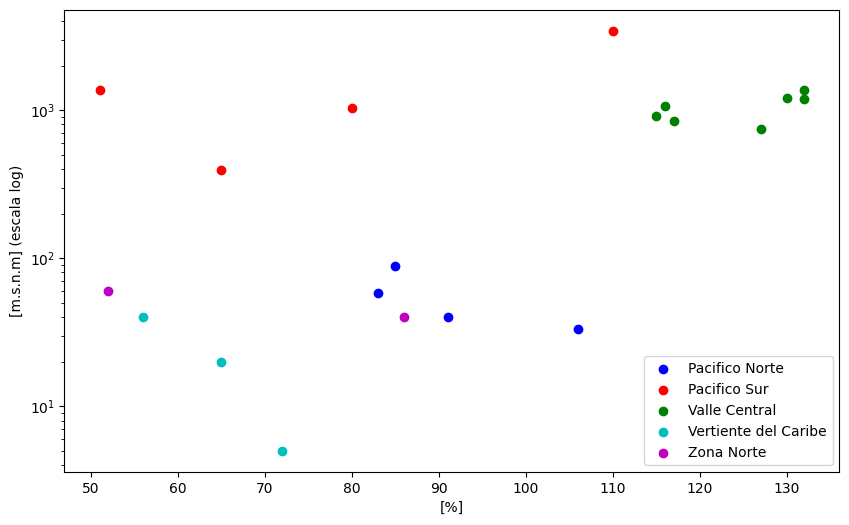

In [19]:
plt.figure(figsize=(10, 6))
# Define color map based on unique values in 'region_climatica'
colors = {'Pacifico Norte': 'b', 
          'Pacifico Sur': 'r', 
          'Valle Central': 'g', 
          'Vertiente del Caribe':'c',
          'Zona Norte':'m' 
          }
    
# Iterate through each region to create scatter plots with appropriate labels
for region, color in colors.items():
    region_data = meta_df[meta_df['region_climatica'] == region]
    plt.scatter((-1)*region_data['percentage_diff'], region_data['Altitud (m.s.n.m.)'], c=color, label=region)

plt.xlabel('[%]')
plt.ylabel('[m.s.n.m] (escala log)')
#plt.title(f'Altitud de EMA vs Diferencia Porcentual')
plt.legend()
plt.yscale('log') 
plt.savefig('./PLOTS/altitud_vs_diff%_LT.png')
plt.show()

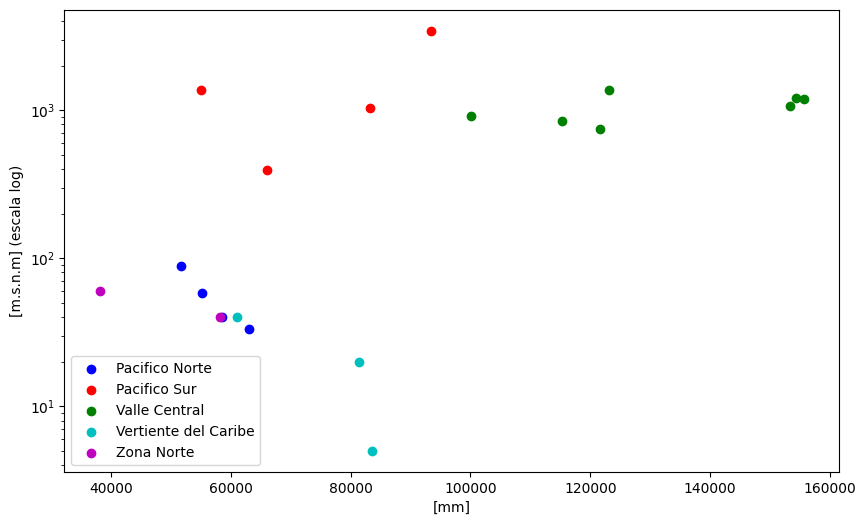

In [18]:
plt.figure(figsize=(10, 6))
# Define color map based on unique values in 'region_climatica'
colors = {'Pacifico Norte': 'b', 
          'Pacifico Sur': 'r', 
          'Valle Central': 'g', 
          'Vertiente del Caribe':'c',
          'Zona Norte':'m' 
          }
    
# Iterate through each region to create scatter plots with appropriate labels
for region, color in colors.items():
    region_data = meta_df[meta_df['region_climatica'] == region]
    plt.scatter((-1)*region_data['diff_accum'], region_data['Altitud (m.s.n.m.)'], c=color, label=region)

plt.xlabel('[mm]')
plt.ylabel('[m.s.n.m] (escala log)')
#plt.title(f'Altitud de EMA vs Diferencia')
plt.legend()
plt.yscale('log') 
plt.savefig('./PLOTS/altitud_vs_diff_LT.png')
plt.show()

### Time Series

In [13]:
# Create a dropdown widget for selecting the column
column_options = list(imn_df.columns)  # Assuming both dataframes have the same columns
column_dropdown = widgets.Dropdown(
    options=column_options,
    value=column_options[0],
    description='Station Number:',
    disabled=False
)

In [14]:
# Create a dropdown widget for selecting resolution
resolution_options = list(temp_resol.keys()) 
resolution_dropdown = widgets.Dropdown(
    options=resolution_options,
    value=resolution_options[2],
    description='Resolution:',
    disabled=False
)

In [15]:
# Create an interactive plot
interactive_plot = widgets.interactive(
    plot_resol,
    df1=widgets.fixed(imn_df),
    df2=widgets.fixed(gpm_df),
    resolution=resolution_dropdown,
    column=column_dropdown
)

# Display the interactive plot
display(interactive_plot)

interactive(children=(Dropdown(description='Resolution:', index=2, options=('1D', '7D', '1M'), value='1M'), Dr…

### Frequency Spectrum

In [16]:
imn_tmp = imn_df.fillna(0)

In [25]:
# Create an interactive plot
interactive_plot = widgets.interactive(
    plot_freq_2,
    df1=widgets.fixed(imn_tmp),
    df2=widgets.fixed(gpm_df),
    column=column_dropdown
)
# Display the interactive plot
display(interactive_plot)

interactive(children=(Dropdown(description='Station Number:', index=2, options=('84141', '69679', '74051', '73…

In [26]:
# Find the top 5 highest signals from Fourier Transform 
d = 3600  # for hourly data

# Find top signals for IMN data
top_signals_IMN = find_top_signals(imn_tmp, d)

# Find top signals for GPM data
top_signals_GPM = find_top_signals(gpm_df, d)

In [29]:
top_signals_IMN

,frequency_1,frequency_2,frequency_3,frequency_4,frequency_5,frequency_6,frequency_7,frequency_8,frequency_9,frequency_10,magnitude_1,magnitude_2,magnitude_3,magnitude_4,magnitude_5,magnitude_6,magnitude_7,magnitude_8,magnitude_9,magnitude_10
84141,1.000,365.227,1.003,0.500,0.997,1.000,1.000,121.742,0.501,382.619,15074.478110,10456.266760,8465.032668,8434.774534,7717.549309,5840.211228,5724.253872,5183.518856,4878.358559,4664.591922
69679,365.227,1.000,0.997,1.003,1.000,382.619,0.500,182.614,8035.000,1.008,8758.797451,8277.083688,4769.302817,4028.472601,3964.625732,3935.347502,3756.919289,3716.634492,2763.607375,2746.331037
74051,365.227,1.000,0.997,121.742,0.500,1.003,182.614,382.619,349.348,1.000,9685.550594,9070.597483,5592.283793,5485.529431,4891.831473,4574.694286,4412.858276,3859.636666,3757.004780,3559.336683
73123,1.000,365.227,1.003,0.997,0.500,1.000,1.008,121.742,0.992,1.000,8457.936694,6142.490589,5027.085253,4833.976239,4470.460005,3602.384679,3105.219876,3080.340010,2932.250839,2892.072234
72157,365.227,1.000,0.997,1.003,382.619,0.500,1.000,349.348,121.742,1.000,11285.582807,10600.454435,6571.161346,5962.732331,4851.128198,4753.434708,4585.180500,4490.241633,4042.902068,3668.136133
98075,1.000,0.500,1.000,365.227,1.000,182.614,0.997,1.003,0.500,1.006,24149.292494,14055.233436,11315.466444,10713.769804,10335.575121,9174.580035,7885.431740,7723.539393,6892.243040,6695.539236
71015,182.614,803.500,730.455,4017.500,669.583,121.742,2008.750,186.860,191.310,1.000,8602.730135,6419.337320,6378.476676,5765.594048,5499.008964,5120.095990,4720.543259,4553.538250,4433.711409,4402.763186
98091,1.000,365.227,1.000,0.500,1.000,182.614,0.997,1.003,121.742,0.995,12685.453634,7410.598278,6280.715032,5754.441699,5514.229275,5447.659161,5217.885399,4760.559209,3793.970958,3770.709572
84139,1.000,365.227,1.003,0.500,0.997,1.000,1.000,0.501,382.619,121.742,15693.837390,10837.621752,8928.708465,8861.143676,8016.364474,6306.392440,6138.065126,5435.585502,4740.270093,4739.684459
81005,182.614,1.000,121.742,186.860,2008.750,60.871,1.003,9.028,1607.000,15.393,7634.165322,6579.665129,4878.831572,4266.081695,4207.674245,3920.622221,3816.145744,3752.832789,3698.969557,3688.622271


In [28]:
# Apply the transformation from frequency to time
for col in top_signals_IMN.columns:
    if 'frequency' in col:
        top_signals_IMN[col] = top_signals_IMN[col].apply(lambda x: 1 / x * (1 / 86400)).round(3)

for col in top_signals_GPM.columns:
    if 'frequency' in col:
        top_signals_GPM[col] = top_signals_GPM[col].apply(lambda x: 1 / x * (1 / 86400)).round(3)

In [15]:
tmp = pd.read_excel('./signals.xls')

In [13]:
tmp[tmp > 500] = np.nan

In [167]:
tmp['EMA'].value_counts(dropna=False)

EMA
1.0      19
365.0    17
0.5      14
182.0     4
121.0     4
NaN       2
Name: count, dtype: int64

In [168]:
tmp['IMERG'].value_counts(dropna=False)

IMERG
365.0    20
1.0      17
0.5      16
0.2       3
182.0     2
121.0     2
Name: count, dtype: int64

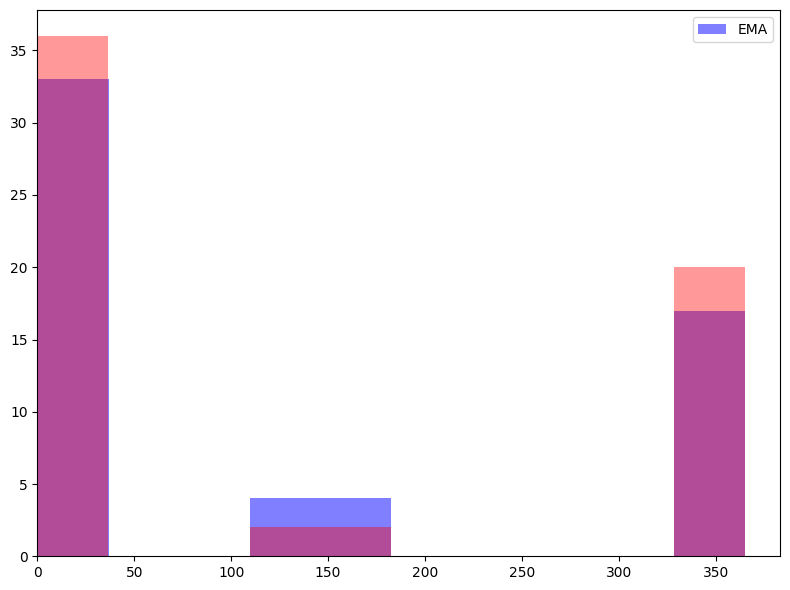

In [163]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.hist(tmp['EMA'], color= 'blue', alpha=0.5, label='EMA')
ax.hist(tmp['IMERG'], color= 'red', alpha=0.4)
ax.legend()
ax.set_xlim(left=0)
fig.tight_layout()
plt.savefig(f'./PLOTS/hist_EF.png')
plt.show()

### Altitude vs Predominant signals

In [29]:
tmp2 = pd.read_excel('./Data/signals_v2.xlsx')

In [44]:
#tmp2['P3_ EMA'][tmp2['P3_ EMA'] > 500] = np.nan

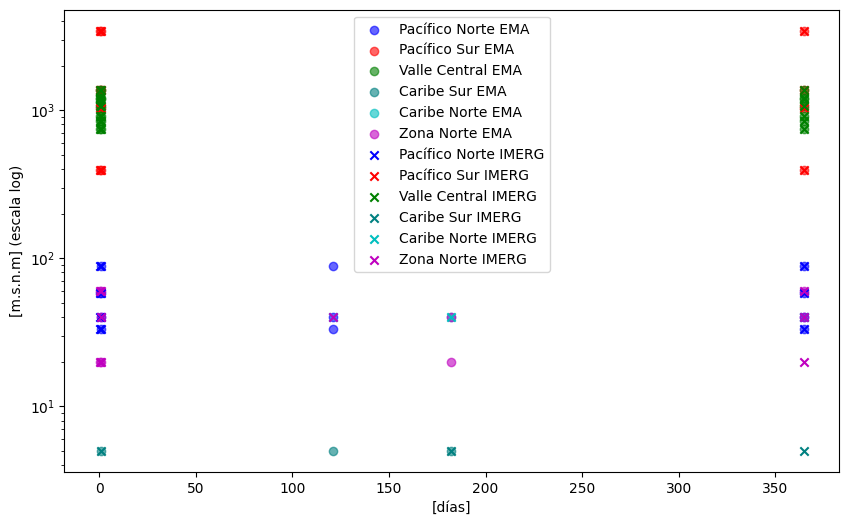

In [53]:
# Scatter plot for EMA
plt.figure(figsize=(10, 6))

colors = {'Pacífico Norte': 'b', 
          'Pacífico Sur': 'r', 
          'Valle Central': 'g', 
          'Caribe Norte':'c',
          'Caribe Sur':'teal',
          'Zona Norte':'m' 
          }

# Scatter plot for EMA
for region in tmp2['region_climatica'].unique():
    region_df = tmp2[tmp2['region_climatica'] == region]
    plt.scatter(region_df['P1_ EMA'], region_df['altitud'], label=f'{region} EMA', color=colors[region], alpha=0.6)
    plt.scatter(region_df['P2_ EMA'], region_df['altitud'], color=colors[region], alpha=0.6)
    plt.scatter(region_df['P3_ EMA'], region_df['altitud'], color=colors[region], alpha=0.6)

# Scatter plot for IMERG
for region in tmp2['region_climatica'].unique():
    region_df = tmp2[tmp2['region_climatica'] == region]
    plt.scatter(region_df['P1_IMERG'], region_df['altitud'], label=f'{region} IMERG', color=colors[region], marker='x')
    plt.scatter(region_df['P2_IMERG'], region_df['altitud'], color=colors[region], marker='x')
    plt.scatter(region_df['P3_IMERG'], region_df['altitud'], color=colors[region], marker='x')

plt.yscale('log') 
plt.xlabel('[días]')
plt.ylabel('[m.s.n.m] (escala log)')
plt.legend()
#plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
#plt.title('Scatter Plot of Precipitation (EMA and IMERG) by Altitude and Region')
plt.show()